# Text Latent Representation Using Tokenization and Word Embeddings

This notebook transforms customer reviews into token IDs, padded sequences, dense word embeddings, flattened feature vectors, and a two-dimensional PCA visualization.

## Dataset

The text is lowercased and tokenized by removing punctuation. Token ID 0 is reserved for padding.

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

sentences = [
    'The product quality is excellent',
    'I really love this product',
    'The quality of this item is amazing',
    'The product performance is poor',
    'I dislike this product completely',
]

tokens = [[word.lower() for word in re.findall(r'[A-Za-z]+', sentence)]
          for sentence in sentences]

for sentence, row in zip(sentences, tokens):
    print(f'{sentence} -> {row}')

The product quality is excellent -> ['the', 'product', 'quality', 'is', 'excellent']
I really love this product -> ['i', 'really', 'love', 'this', 'product']
The quality of this item is amazing -> ['the', 'quality', 'of', 'this', 'item', 'is', 'amazing']
The product performance is poor -> ['the', 'product', 'performance', 'is', 'poor']
I dislike this product completely -> ['i', 'dislike', 'this', 'product', 'completely']


## 1 Vocabulary and token IDs

In [2]:
vocab = {}
for row in tokens:
    for word in row:
        if word not in vocab:
            vocab[word] = len(vocab) + 1

print('Vocabulary:')
for word, token_id in vocab.items():
    print(f'{word:12} -> {token_id}')

token_sequences = [[vocab[word] for word in row] for row in tokens]
print('\nToken sequences:')
for i, sequence in enumerate(token_sequences, 1):
    print(f'Sample {i}: {sequence}')

Vocabulary:
the          -> 1
product      -> 2
quality      -> 3
is           -> 4
excellent    -> 5
i            -> 6
really       -> 7
love         -> 8
this         -> 9
of           -> 10
item         -> 11
amazing      -> 12
performance  -> 13
poor         -> 14
dislike      -> 15
completely   -> 16

Token sequences:
Sample 1: [1, 2, 3, 4, 5]
Sample 2: [6, 7, 8, 9, 2]
Sample 3: [1, 3, 10, 9, 11, 4, 12]
Sample 4: [1, 2, 13, 4, 14]
Sample 5: [6, 15, 9, 2, 16]


## 2 Padding token sequences

In [3]:
PAD_ID = 0
max_length = max(len(sequence) for sequence in token_sequences)
padded_sequences = np.array([
    sequence + [PAD_ID] * (max_length - len(sequence))
    for sequence in token_sequences
])

print(f'Maximum sequence length: {max_length}')
print('Padded token sequences:')
print(padded_sequences)

Maximum sequence length: 7
Padded token sequences:
[[ 1  2  3  4  5  0  0]
 [ 6  7  8  9  2  0  0]
 [ 1  3 10  9 11  4 12]
 [ 1  2 13  4 14  0  0]
 [ 6 15  9  2 16  0  0]]


## 3 Word embeddings

Each token is mapped to a reproducible four-dimensional dense vector. These are illustrative embeddings generated with a fixed seed, not pretrained semantic embeddings. Padding maps to the zero vector.

In [4]:
embedding_dimension = 4
rng = np.random.default_rng(7)
embedding_matrix = np.zeros((len(vocab) + 1, embedding_dimension))
embedding_matrix[1:] = rng.normal(0, 1, (len(vocab), embedding_dimension)).round(3)

print('Embedding for each vocabulary word:')
for word, token_id in vocab.items():
    print(f'{word:12} {embedding_matrix[token_id]}')

sentence_embedding_matrices = embedding_matrix[padded_sequences]
for i, matrix in enumerate(sentence_embedding_matrices, 1):
    print(f'\nSample {i} embedding matrix:')
    print(matrix)

Embedding for each vocabulary word:
the          [ 0.001  0.299 -0.274 -0.891]
product      [-0.455 -0.992  0.06   1.34 ]
quality      [-0.492 -0.62   0.49   0.357]
is           [ 0.105 -0.93  -0.029  0.695]
excellent    [-1.344 -0.458 -1.901 -1.29 ]
i            [-1.842 -0.235 -1.267  0.271]
really       [ 0.157 -0.187 -2.517 -0.539]
love         [-0.049  0.113 -1.53  -0.478]
this         [-0.979 -0.809  1.061 -0.808]
of           [-0.033  0.884 -0.584 -0.112]
item         [ 0.11   0.064 -1.225  0.076]
amazing      [ 1.359 -1.547  0.859  0.119]
performance  [-0.641  2.     0.762 -1.199]
poor         [ 0.075  0.577 -0.189  0.683]
dislike      [-0.067  0.667  1.439 -0.676]
completely   [ 0.203 -0.463  0.127 -1.187]

Sample 1 embedding matrix:
[[ 1.000e-03  2.990e-01 -2.740e-01 -8.910e-01]
 [-4.550e-01 -9.920e-01  6.000e-02  1.340e+00]
 [-4.920e-01 -6.200e-01  4.900e-01  3.570e-01]
 [ 1.050e-01 -9.300e-01 -2.900e-02  6.950e-01]
 [-1.344e+00 -4.580e-01 -1.901e+00 -1.290e+00]
 [ 0.000e+00 

## 4 Flattened feature vectors

In [5]:
flattened_vectors = sentence_embedding_matrices.reshape(len(sentences), -1)
print(f'Flattened vector shape: {flattened_vectors.shape}')
for i, vector in enumerate(flattened_vectors, 1):
    print(f'Sample {i}: {vector}')

# Small self-check for the core transformation.
assert padded_sequences.shape == (5, 7)
assert sentence_embedding_matrices.shape == (5, 7, 4)
assert flattened_vectors.shape == (5, 28)
assert np.all(sentence_embedding_matrices[padded_sequences == PAD_ID] == 0)
print('Self-check passed.')

Flattened vector shape: (5, 28)
Sample 1: [ 1.000e-03  2.990e-01 -2.740e-01 -8.910e-01 -4.550e-01 -9.920e-01
  6.000e-02  1.340e+00 -4.920e-01 -6.200e-01  4.900e-01  3.570e-01
  1.050e-01 -9.300e-01 -2.900e-02  6.950e-01 -1.344e+00 -4.580e-01
 -1.901e+00 -1.290e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00
  0.000e+00  0.000e+00  0.000e+00  0.000e+00]
Sample 2: [-1.842 -0.235 -1.267  0.271  0.157 -0.187 -2.517 -0.539 -0.049  0.113
 -1.53  -0.478 -0.979 -0.809  1.061 -0.808 -0.455 -0.992  0.06   1.34
  0.     0.     0.     0.     0.     0.     0.     0.   ]
Sample 3: [ 1.000e-03  2.990e-01 -2.740e-01 -8.910e-01 -4.920e-01 -6.200e-01
  4.900e-01  3.570e-01 -3.300e-02  8.840e-01 -5.840e-01 -1.120e-01
 -9.790e-01 -8.090e-01  1.061e+00 -8.080e-01  1.100e-01  6.400e-02
 -1.225e+00  7.600e-02  1.050e-01 -9.300e-01 -2.900e-02  6.950e-01
  1.359e+00 -1.547e+00  8.590e-01  1.190e-01]
Sample 4: [ 1.000e-03  2.990e-01 -2.740e-01 -8.910e-01 -4.550e-01 -9.920e-01
  6.000e-02  1.340e+00 -6.410e-01 

## 5 PCA visualization of word embeddings

PCA reduces each word vector from four dimensions to two principal components.

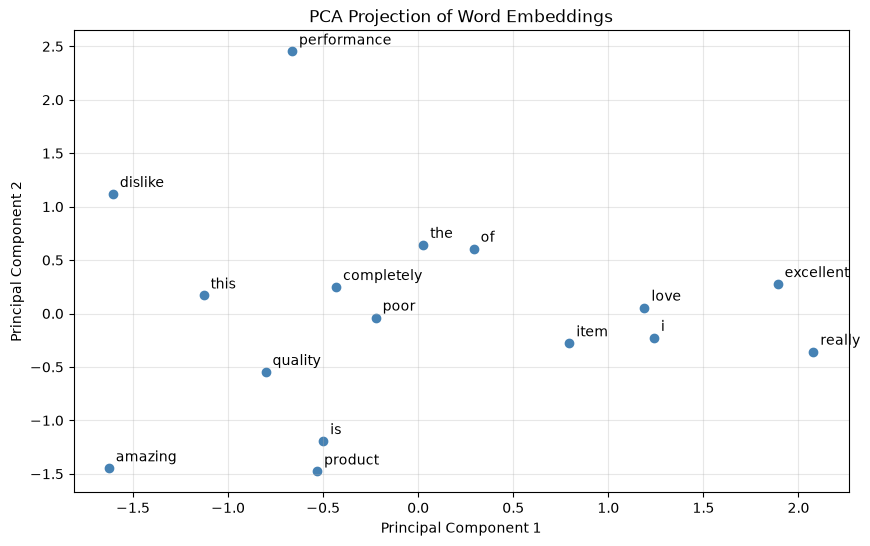

In [6]:
word_vectors = embedding_matrix[1:]
centered = word_vectors - word_vectors.mean(axis=0)
_, _, vh = np.linalg.svd(centered, full_matrices=False)
pca_coordinates = centered @ vh[:2].T

plt.figure(figsize=(10, 6))
plt.scatter(pca_coordinates[:, 0], pca_coordinates[:, 1], color='steelblue')
for word, token_id in vocab.items():
    x, y = pca_coordinates[token_id - 1]
    plt.annotate(word, (x, y), xytext=(5, 5), textcoords='offset points')
plt.title('PCA Projection of Word Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.3)
plt.show()

## Conclusion

Tokenization converts the reviews into discrete IDs. Padding makes all samples the same length, embeddings convert IDs into dense vectors, and flattening creates a fixed-length 28-value representation for each review. PCA provides a two-dimensional view of the illustrative embedding space.